# Импорт библиотек

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import DATASETS_DIR
from ydata_profiling import ProfileReport



c:\diploma\diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline

In [3]:
MIN_WELL_RECORDS = 50
D_DEPTH_UPPER    = 0.5
ROTATION_LOWER   = 50
ROTATION_UPPER   = 250
SPEED_LOWER      = 0.0001

# Начальный просмотр данных

In [4]:
df1 = pd.read_csv(DATASETS_DIR / "dataset_1.csv")
df2 = pd.read_csv(DATASETS_DIR / "dataset_2.csv")

df1.to_pickle(DATASETS_DIR / "dataset_1.pkl")
df2.to_pickle(DATASETS_DIR / "dataset_2.pkl")

In [5]:
df1.shape

(165966, 39)

# Препроцесс

<h3>Удаление различающихся колонок

In [6]:
common_cols = df1.columns.intersection(df2.columns)
df1 = df1[common_cols]
df2 = df2[common_cols]

In [7]:
df1.columns

Index(['id', 'time', 'processing_time', 'lon', 'lat', 'height', 'depth',
       'course', 'angle', 'num_sattelites', 'moving_type', 'rotation',
       'rod_change', 'pressure_air', 'pressure_axis', 'pressure_rotation',
       'electric_rotation', 'electric_pressure_axis', 'voltage_rotation',
       'voltage_pressure_axis', 'time_stamp', 'sequence_id', 'block_well_id',
       'rig_id', 'well_id', 'drilling_speed', 'rtk_status', 'd_depth',
       'd_time', 'speed', 'n/p', 'EI', 'EI 0-1', 'EI 1-2'],
      dtype='object')

<h3>Исправление ошибки

колонка depth = d_depth

In [8]:
df2['depth'].equals(df2['d_depth'])

True

In [9]:
df2 = df2.sort_values(['well_id', 'time']).reset_index(drop=True)
df2['d_depth'] = df2.groupby('well_id')['depth'].diff()
df2 = df2.dropna(subset=['d_depth']).copy()
df2 = df2[df2['d_depth'] > 0].copy()
df2['speed'] = df2['d_depth'] / df2['d_time']
df2['EI'] = (df2['pressure_axis'] * df2['pressure_rotation'] * df2['rotation']) / df2['speed']

<h3> Объединение

In [10]:
df1['source'] = 'df1'
df2['source'] = 'df2'

common_cols = [c for c in df1.columns if c in df2.columns]
df = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)

print(f'\n Объединённый датасет: {len(df)} строк, {df["well_id"].nunique()} скважин')


 Объединённый датасет: 437510 строк, 2071 скважин


In [11]:
df['time'] = pd.to_datetime(df['time'])
df['processing_time'] = pd.to_datetime(df['processing_time'])

<h3> удаление пустых строк, выбросов, скважин с маленьким количеством записей и экстремальных speed

In [12]:
def preprocess(df, name):
    print(f'\n{name}: {len(df)} строк, {df["well_id"].nunique()} скважин')
    
    # 1. NaN / inf / неположительные
    df = df.dropna(subset=['speed', 'EI']).copy()
    df = df[(df['speed'] > 0) & np.isfinite(df['EI']) & (df['EI'] > 0)].copy()
    print(f'  NaN/inf: {len(df)}')
    
    # 2. Физические фильтры
    df = df[df['d_depth'] <= D_DEPTH_UPPER].copy()
    print(f'  d_depth ≤ {D_DEPTH_UPPER}: {len(df)}')
    
    df = df[df['rotation'] >= ROTATION_LOWER].copy()
    print(f'  rotation ≥ {ROTATION_LOWER}: {len(df)}')
    
    df = df[df['rotation'] <= ROTATION_UPPER].copy()
    print(f'  rotation ≤ {ROTATION_UPPER}: {len(df)}')
    
    # 3. Нижний порог speed (убирает экстремальные EI)
    df = df[df['speed'] >= SPEED_LOWER].copy()
    print(f'  speed ≥ {SPEED_LOWER}: {len(df)}')
    
    # 4. Фильтр скважин ПОСЛЕ всех остальных фильтров
    wc = df.groupby('well_id').size().reset_index(name='count')
    df = df[df['well_id'].isin(wc[wc['count'] >= MIN_WELL_RECORDS]['well_id'])].copy()
    print(f'  Скважины ≥ {MIN_WELL_RECORDS}: {len(df)} ({df["well_id"].nunique()} скважин)')
    
    df['log_EI'] = np.log10(df['EI'])
    
    # 5. Сброс индекса
    df = df.reset_index(drop=True)
    
    return df
df = preprocess(df, 'df')


df: 437510 строк, 2071 скважин
  NaN/inf: 437080
  d_depth ≤ 0.5: 433930
  rotation ≥ 50: 430591
  rotation ≤ 250: 426584
  speed ≥ 0.0001: 426540
  Скважины ≥ 50: 423124 (1714 скважин)


<h3> удаление ненужных колонок

In [13]:
cols_to_drop = ['id', 'time', 'lon', 'lat', 'height', 'course', 'angle', 'num_sattelites', 'moving_type', 'rod_change', 'pressure_air',
                'electric_rotation', 'electric_pressure_axis', 'voltage_rotation', 'voltage_pressure_axis', 'time_stamp', 'sequence_id',
                'block_well_id', 'rig_id', 'drilling_speed', 'rtk_status', 'EI 0-1', 'EI 1-2']
df_cleaned = df.drop(columns=cols_to_drop)

# Профайлеры 

<h3> сырой датасет

In [14]:
# profile = ProfileReport(df, title="Drilling Data Profile", explorative=True)
# profile.to_file("report.html")

<h3> предобработанный датасет

In [16]:
profile = ProfileReport(df_cleaned, title="Drilling Data Profile", explorative=True)
profile.to_file("report_cleaned.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 31.51it/s]


# Сравнение распределений

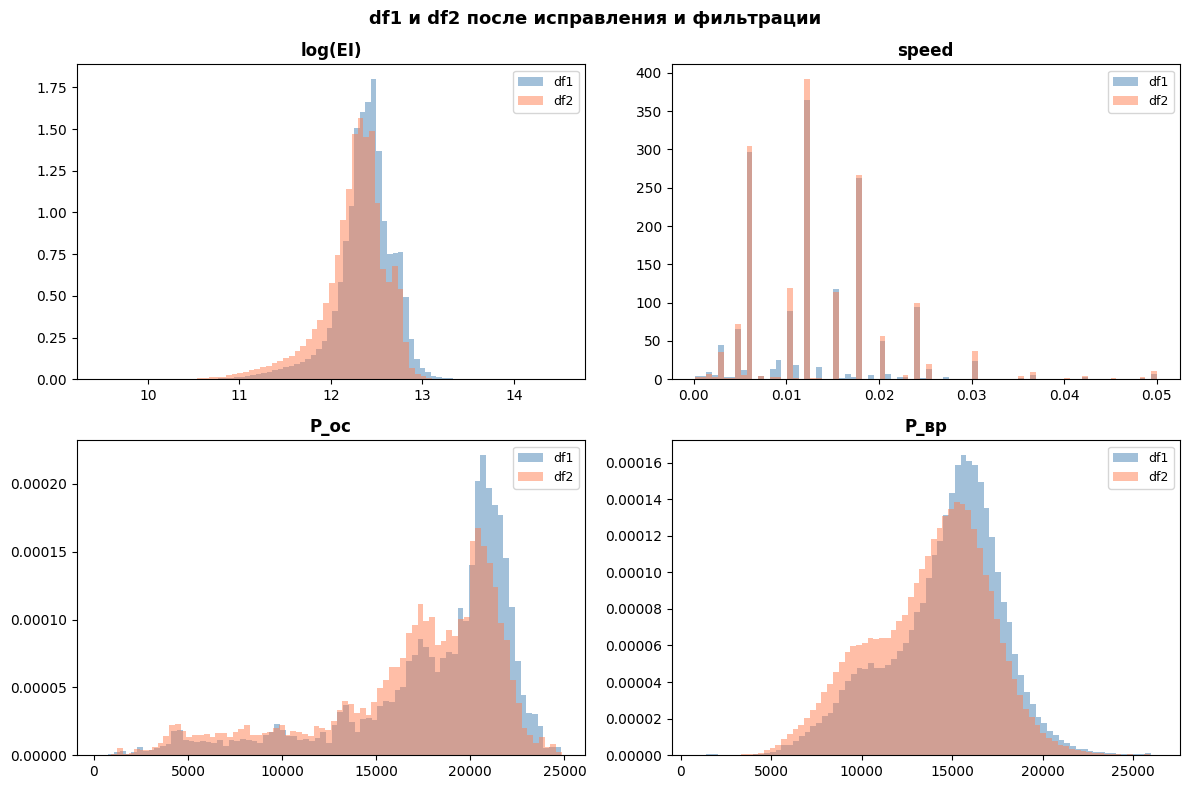

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten() 

cols = ['log_EI', 'speed', 'pressure_axis', 'pressure_rotation']
titles = ['log(EI)', 'speed', 'P_ос', 'P_вр']
xlims = [None, (0, 0.05), None, None]

for ax, col, title, xlim in zip(axes, cols, titles, xlims):
    d1 = df[df['source']=='df1'][col]
    d2 = df[df['source']=='df2'][col]
    
    if xlim:
        d1, d2 = d1.clip(*xlim), d2.clip(*xlim)
    
    ax.hist(d1, bins=80, alpha=0.5, density=True, label='df1', color='steelblue')
    ax.hist(d2, bins=80, alpha=0.5, density=True, label='df2', color='coral')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('df1 и df2 после исправления и фильтрации', fontsize=13, fontweight='bold')
plt.tight_layout()  
plt.show()

# Снижение размера датасета

In [18]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423124 entries, 0 to 423123
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   processing_time    423124 non-null  datetime64[ns]
 1   depth              423124 non-null  float64       
 2   rotation           423124 non-null  float64       
 3   pressure_axis      423124 non-null  int64         
 4   pressure_rotation  423124 non-null  int64         
 5   well_id            423124 non-null  int64         
 6   d_depth            423124 non-null  float64       
 7   d_time             423124 non-null  float64       
 8   speed              423124 non-null  float64       
 9   n/p                423124 non-null  float64       
 10  EI                 423124 non-null  float64       
 11  source             423124 non-null  object        
 12  log_EI             423124 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(3), 

In [19]:
df_cleaned['pressure_axis'] = df_cleaned['pressure_axis'].astype(np.int16)
df_cleaned['pressure_rotation'] = df_cleaned['pressure_rotation'].astype(np.int16)
df_cleaned['well_id'] = df_cleaned['well_id'].astype(np.int32)

float_cols = ['depth','rotation','d_depth','d_time','speed','EI','log_EI', 'n/p']
df_cleaned[float_cols] = df_cleaned[float_cols].astype(np.float32)
df_cleaned['source'] = df_cleaned['source'].astype('category')


In [20]:
df_cleaned.drop(columns=['d_depth', 'd_time', 'n/p', 'EI', 'depth'], inplace=True)

In [21]:
df_cleaned.to_csv(DATASETS_DIR / "cleaned_dataset.csv")

In [22]:
df_cleaned.to_pickle('df_cleaned.pkl')

In [23]:
df_cleaned.columns

Index(['processing_time', 'rotation', 'pressure_axis', 'pressure_rotation',
       'well_id', 'speed', 'source', 'log_EI'],
      dtype='object')

In [24]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423124 entries, 0 to 423123
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   processing_time    423124 non-null  datetime64[ns]
 1   rotation           423124 non-null  float32       
 2   pressure_axis      423124 non-null  int16         
 3   pressure_rotation  423124 non-null  int16         
 4   well_id            423124 non-null  int32         
 5   speed              423124 non-null  float32       
 6   source             423124 non-null  category      
 7   log_EI             423124 non-null  float32       
dtypes: category(1), datetime64[ns](1), float32(3), int16(2), int32(1)
memory usage: 11.7 MB
